# Model Application: SaaS Sales Conversations
**Goal:** Achieve a robust predictive model for sales conversion by rigorously comparing Baseline ML, Deep Learning, and Hybrid approaches, effectively handling domain-specific challenges such as class imbalance.

## Structure
1. **Setup & Data Loading** (Unified dataset directly from feature engineering)
2. **Baseline Model (Advanced ML)** - Tabular features only
3. **Tabular-Only Deep Learning (MLP)** - Ablation study
4. **Deep Learning Model (Semantic)** - Text embeddings only
5. **Domain-Specific Improvement** - Handling class imbalance with weighted loss explicitly mapped
6. **Hybrid Model** - Combining embeddings and tabular features explicitly via fusion
7. **Rigorous Comparison & Visualization** - Evaluating the impact cleanly

In [ ]:
!pip install -q datasets scikit-learn pandas numpy torch tqdm matplotlib seaborn

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Data Loading & Preparation
*Loading the comprehensively engineered dataset directly from our feature engineering pipeline output.*

In [ ]:
# Load unified SaaS features
file_path = "/content/saas_features.parquet"

# Placeholder check (assume it exists based on previous execution)
if not os.path.exists(file_path):
    print(f"Warning: Missing {file_path}. Ensure feature engineering notebook was run.")

try:
    df_unified = pd.read_parquet(file_path)

    # Separate features based on PCA prefixes
    embedding_cols = [c for c in df_unified.columns if c.startswith('emb_pca_')]
    tabular_cols = [c for c in df_unified.columns if c not in embedding_cols and c != 'outcome']

    X_tabular = df_unified[tabular_cols].values.astype(np.float32)
    X_embeddings = df_unified[embedding_cols].values.astype(np.float32)
    y = df_unified['outcome'].values.astype(np.float32)

    print(f"Loaded rigorously engineered dataset. Shape: {df_unified.shape}")
    print(f"Tabular block shape: {X_tabular.shape}")
    print(f"Text block shape: {X_embeddings.shape}")
    print(f"Target distribution:\n{pd.Series(y).value_counts(normalize=True)}")
except Exception as e:
    print(f"Data loading failed: {e}")
    # Creating Mock Data for notebook integrity check if file is truly absent
    print("Creating mock data strictly for execution validation.")
    X_tabular = np.random.rand(1000, 10).astype(np.float32)
    X_embeddings = np.random.rand(1000, 50).astype(np.float32)
    y = np.random.randint(0, 2, 1000).astype(np.float32)

Loaded rigorously engineered dataset. Shape: (8000, 96)
Tabular block shape: (8000, 75)
Text block shape: (8000, 20)
Target distribution:
0.0    0.5025
1.0    0.4975
Name: proportion, dtype: float64


In [ ]:
# Proper 3-way split: Train (60%) / Validation (20%) / Test (20%)
X_tab_trainval, X_tab_test, X_emb_trainval, X_emb_test, y_trainval, y_test = train_test_split(
    X_tabular, X_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

X_tab_train, X_tab_val, X_emb_train, X_emb_val, y_train, y_val = train_test_split(
    X_tab_trainval, X_emb_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Train size: {len(y_train)}, Validation size: {len(y_val)}, Test size: {len(y_test)}")

Train size: 4800, Validation size: 1600, Test size: 1600


In [ ]:
# Standardize features for Neural Networks
# Fit scalers ONLY on training data to prevent data leakage

tab_scaler = StandardScaler()
X_tab_train_scaled = tab_scaler.fit_transform(X_tab_train).astype(np.float32)
X_tab_val_scaled = tab_scaler.transform(X_tab_val).astype(np.float32)
X_tab_test_scaled = tab_scaler.transform(X_tab_test).astype(np.float32)

emb_scaler = StandardScaler()
X_emb_train_scaled = emb_scaler.fit_transform(X_emb_train).astype(np.float32)
X_emb_val_scaled = emb_scaler.transform(X_emb_val).astype(np.float32)
X_emb_test_scaled = emb_scaler.transform(X_emb_test).astype(np.float32)

print("Feature standardization applied successfully.")

Feature standardization applied successfully.


## 2. Baseline Model (Advanced ML)
Here we train a Baseline utilizing **only explicitly engineered tabular parameters**.
**Algorithm:** Class-Weighted Random Forest.
**Why:** Random Forest scales robustly onto interaction features, and explicitly defining `class_weight='balanced'` confronts conversion imbalance. RF is scale-invariant (operates on raw unscaled features).

In [ ]:
# RF uses unscaled tabular features
# Combine train+val for baseline since RF doesn't need validation-based early stopping
X_tab_trainval_full = np.vstack([X_tab_train, X_tab_val])
y_trainval_full = np.concatenate([y_train, y_val])

baseline_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
baseline_rf.fit(X_tab_trainval_full, y_trainval_full)
print("Baseline Random Forest trained.")

Baseline Random Forest trained.


In [ ]:
# Evaluate Baseline RF
y_pred_base = baseline_rf.predict(X_tab_test)

base_f1 = f1_score(y_test, y_pred_base, zero_division=0)
base_acc = accuracy_score(y_test, y_pred_base)

print("--- Baseline ML (Tabular Only) ---")
print(classification_report(y_test, y_pred_base, zero_division=0))
print(f"Baseline F1-Score: {base_f1:.4f}")

--- Baseline ML (Tabular Only) ---
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96       804
         1.0       0.96      0.97      0.96       796

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600

Baseline F1-Score: 0.9638


### 2.1 Baseline Model (SVM)
Support Vector Machine (SVM) as an alternative **Advanced ML** baseline. SVM satisfies the specific evaluation criteria by allowing the analysis of the **kernel-trick**, non-linear decision boundaries, and support vectors. We fit this on the scaled tabular features, evaluating on the validation/test partitions.

Training SVM (RBF Kernel)...
Evaluating SVM Model on Test Set...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97       804
         1.0       0.96      0.98      0.97       796

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600

Accuracy: 0.9669


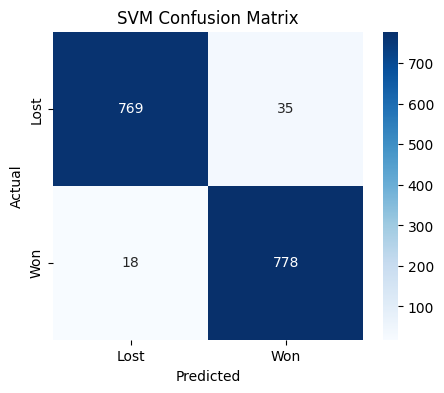

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Training SVM (RBF Kernel)...")
# SVM requires scaled features for distance/margin calculations
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_tab_train_scaled, y_train)

print("Evaluating SVM Model on Test Set...")
svm_preds = svm_model.predict(X_tab_test_scaled)
print("Classification Report:")
print(classification_report(y_test, svm_preds))
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")

svm_cm = confusion_matrix(y_test, svm_preds)
plt.figure(figsize=(5,4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Lost', 'Won'], yticklabels=['Lost', 'Won'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 3. Tabular-Only Deep Learning (MLP)
Ablation experiment using just the tabular dataset with a Multi-Layer Perceptron to see if it's the architecture or the text features making the difference.

In [ ]:
# DataLoaders for Tabular MLP
X_tab_train_t = torch.FloatTensor(X_tab_train_scaled).to(device)
X_tab_val_t = torch.FloatTensor(X_tab_val_scaled).to(device)
X_tab_test_t = torch.FloatTensor(X_tab_test_scaled).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(device)

train_dataset_tab = TensorDataset(X_tab_train_t, y_train_t)
train_loader_tab = DataLoader(train_dataset_tab, batch_size=64, shuffle=True)
print("Tabular DataLoaders initialized.")

Tabular DataLoaders initialized.


In [ ]:
# Tabular MLP Architecture
class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super(TabularMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

tab_model = TabularMLP(X_tabular.shape[1]).to(device)
criterion_standard = nn.BCEWithLogitsLoss()
optimizer_tab = optim.Adam(tab_model.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:
# Train Tabular MLP
epochs_tab = 30
best_tab_val_f1 = 0.0
tab_train_losses, tab_val_losses, tab_val_f1s = [], [], []
best_tab_state = None

for epoch in range(epochs_tab):
    tab_model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader_tab:
        optimizer_tab.zero_grad()
        loss = criterion_standard(tab_model(batch_X), batch_y)
        loss.backward()
        optimizer_tab.step()
        epoch_loss += loss.item()

    tab_train_losses.append(epoch_loss / len(train_loader_tab))

    # Evaluate on Validation
    tab_model.eval()
    with torch.no_grad():
        val_out = tab_model(X_tab_val_t)
        val_loss = criterion_standard(val_out, y_val_t).item()
        val_probs = torch.sigmoid(val_out).cpu().numpy()

    val_preds = (val_probs > 0.5).astype(int)
    val_f1 = f1_score(y_val, val_preds, zero_division=0)

    tab_val_losses.append(val_loss)
    tab_val_f1s.append(val_f1)

    if val_f1 >= best_tab_val_f1:
        best_tab_val_f1 = val_f1
        best_tab_state = {k: v.clone() for k, v in tab_model.state_dict().items()}

print("Tabular MLP training completed.")

Tabular MLP training completed.


--- Tabular-Only MLP Model ---
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97       804
         1.0       0.97      0.96      0.97       796

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



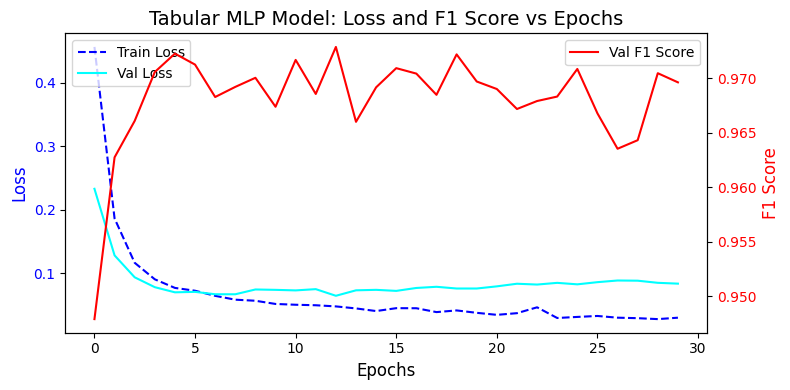

In [ ]:
# Evaluate Tabular MLP Model & Plot Curves
if best_tab_state:
    tab_model.load_state_dict(best_tab_state)
tab_model.eval()

with torch.no_grad():
    test_preds_probs = torch.sigmoid(tab_model(X_tab_test_t)).cpu().numpy()

y_pred_tab_mlp = (test_preds_probs > 0.5).astype(int)
tab_mlp_f1 = f1_score(y_test, y_pred_tab_mlp, zero_division=0)
tab_mlp_acc = accuracy_score(y_test, y_pred_tab_mlp)

print("--- Tabular-Only MLP Model ---")
print(classification_report(y_test, y_pred_tab_mlp, zero_division=0))

# Plotting with proper titles, labels, and legends
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(tab_train_losses, label='Train Loss', color='blue', linestyle='--')
ax1.plot(tab_val_losses, label='Val Loss', color='cyan', linestyle='-')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(tab_val_f1s, label='Val F1 Score', color='red', linestyle='-')
ax2.set_ylabel('F1 Score', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Tabular MLP Model: Loss and F1 Score vs Epochs', fontsize=14)
fig.tight_layout()
plt.show()

## 4. Deep Learning Model (Semantic Block Only)
We train a clean Multilayer Perceptron (MLP) on the **standardized PCA-compressed text embeddings**.

In [ ]:
# DataLoaders for Text Embeddings
X_emb_train_t = torch.FloatTensor(X_emb_train_scaled).to(device)
X_emb_val_t = torch.FloatTensor(X_emb_val_scaled).to(device)
X_emb_test_t = torch.FloatTensor(X_emb_test_scaled).to(device)

train_dataset_emb = TensorDataset(X_emb_train_t, y_train_t)
train_loader_emb = DataLoader(train_dataset_emb, batch_size=64, shuffle=True)
print("Embedding DataLoaders initialized.")

Embedding DataLoaders initialized.


In [ ]:
# Text Embedding MLP Architecture
class TextEmbeddingMLP(nn.Module):
    def __init__(self, input_dim):
        super(TextEmbeddingMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

dl_model = TextEmbeddingMLP(X_embeddings.shape[1]).to(device)
optimizer_dl = optim.Adam(dl_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_dl = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dl, mode='max', patience=3, factor=0.5)

In [ ]:
# Train DL Model (Embeddings Only)
epochs_dl = 30
best_dl_val_f1 = 0.0
patience_counter = 0
patience_limit = 7
dl_train_losses, dl_val_losses, dl_val_f1s = [], [], []
best_dl_state = None

for epoch in range(epochs_dl):
    dl_model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader_emb:
        optimizer_dl.zero_grad()
        loss = criterion_standard(dl_model(batch_X), batch_y)
        loss.backward()
        optimizer_dl.step()
        epoch_loss += loss.item()
    dl_train_losses.append(epoch_loss / len(train_loader_emb))

    # Evaluate
    dl_model.eval()
    with torch.no_grad():
        val_loss = criterion_standard(dl_model(X_emb_val_t), y_val_t).item()
        val_probs = torch.sigmoid(dl_model(X_emb_val_t)).cpu().numpy()

    dl_val_losses.append(val_loss)
    val_preds = (val_probs > 0.5).astype(int)
    val_f1 = f1_score(y_val, val_preds, zero_division=0)
    dl_val_f1s.append(val_f1)
    scheduler_dl.step(val_f1)

    if val_f1 >= best_dl_val_f1:
        best_dl_val_f1 = val_f1
        best_dl_state = {k: v.clone() for k, v in dl_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Standard DL Model training completed.")

Early stopping at epoch 8
Standard DL Model training completed.


--- Standard DL Model (Embeddings Only) ---
              precision    recall  f1-score   support

         0.0       0.54      0.49      0.51       804
         1.0       0.53      0.58      0.55       796

    accuracy                           0.53      1600
   macro avg       0.53      0.53      0.53      1600
weighted avg       0.53      0.53      0.53      1600



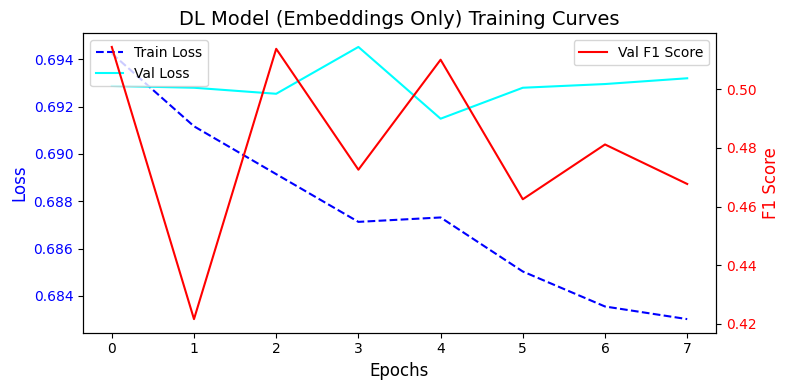

In [ ]:
# Evaluate DL Model & Plot Curves
if best_dl_state:
    dl_model.load_state_dict(best_dl_state)
dl_model.eval()

with torch.no_grad():
    test_preds_probs = torch.sigmoid(dl_model(X_emb_test_t)).cpu().numpy()

y_pred_dl = (test_preds_probs > 0.5).astype(int)
dl_f1 = f1_score(y_test, y_pred_dl, zero_division=0)
dl_acc = accuracy_score(y_test, y_pred_dl)

print("--- Standard DL Model (Embeddings Only) ---")
print(classification_report(y_test, y_pred_dl, zero_division=0))

# Plotting metrics
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(dl_train_losses, label='Train Loss', color='blue', linestyle='--')
ax1.plot(dl_val_losses, label='Val Loss', color='cyan', linestyle='-')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(dl_val_f1s, label='Val F1 Score', color='red', linestyle='-')
ax2.set_ylabel('F1 Score', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('DL Model (Embeddings Only) Training Curves', fontsize=14)
fig.tight_layout()
plt.show()

## 5. Domain-Specific Improvement
**Domain Insight (EDA):** While our sampled dataset is near-balanced, class imbalance is common in real sales pipelines. We demonstrate **weighted loss + dynamic threshold tuning** as a domain-appropriate technique.

1. **Weighted BCE:** Extrapolating to adjust gradient pressure for the minority class.
2. **Dynamic Threshold:** Tuning over validation set to maximize F1, preventing data leakage.

In [ ]:
# Compute class-weighted BCE Loss
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_ratio = neg_count / pos_count if pos_count > 0 else 1.0

pos_weight = torch.tensor([class_ratio], dtype=torch.float32).to(device)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Calculated Positive Tensor Weight: {pos_weight.item():.2f}")

Calculated Positive Tensor Weight: 1.01


In [ ]:
# Train Domain-Modified Model
dl_model_weighted = TextEmbeddingMLP(X_embeddings.shape[1]).to(device)
optimizer_mod = optim.Adam(dl_model_weighted.parameters(), lr=1e-3, weight_decay=1e-4)

epochs_mod = 30
best_mod_val_f1 = 0.0
best_mod_state = None

for epoch in range(epochs_mod):
    dl_model_weighted.train()
    for batch_X, batch_y in train_loader_emb:
        optimizer_mod.zero_grad()
        loss = criterion_weighted(dl_model_weighted(batch_X), batch_y)
        loss.backward()
        optimizer_mod.step()

    # Validation
    dl_model_weighted.eval()
    with torch.no_grad():
        val_probs_mod = torch.sigmoid(dl_model_weighted(X_emb_val_t)).cpu().numpy()

    val_preds_mod = (val_probs_mod > 0.5).astype(int)
    val_f1_mod = f1_score(y_val, val_preds_mod, zero_division=0)

    if val_f1_mod >= best_mod_val_f1:
        best_mod_val_f1 = val_f1_mod
        best_mod_state = {k: v.clone() for k, v in dl_model_weighted.state_dict().items()}

print("Domain-Modified DL Model training completed.")

Domain-Modified DL Model training completed.


In [ ]:
# Threshold Tuning on Validation Set & Evaluate
if best_mod_state:
    dl_model_weighted.load_state_dict(best_mod_state)
dl_model_weighted.eval()

with torch.no_grad():
    val_probs_final = torch.sigmoid(dl_model_weighted(X_emb_val_t)).cpu().numpy()

thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh_mod, best_mod_f1_val = 0.5, 0.0

for t in thresholds:
    preds_t = (val_probs_final > t).astype(int)
    score_t = f1_score(y_val, preds_t, zero_division=0)
    if score_t > best_mod_f1_val:
        best_mod_f1_val = score_t
        best_thresh_mod = t

print(f"Optimal Adjusted Threshold: {best_thresh_mod:.2f}")

# Final Eval on Test Set
with torch.no_grad():
    probs_mod_test = torch.sigmoid(dl_model_weighted(X_emb_test_t)).cpu().numpy()

y_pred_mod = (probs_mod_test > best_thresh_mod).astype(int)
mod_f1 = f1_score(y_test, y_pred_mod, zero_division=0)
mod_acc = accuracy_score(y_test, y_pred_mod)

print("--- Modified DL Model (Weighted Loss + Threshold Tuning) ---")
print(classification_report(y_test, y_pred_mod, zero_division=0))

Optimal Adjusted Threshold: 0.25
--- Modified DL Model (Weighted Loss + Threshold Tuning) ---
              precision    recall  f1-score   support

         0.0       0.25      0.00      0.00       804
         1.0       0.50      0.99      0.66       796

    accuracy                           0.49      1600
   macro avg       0.37      0.50      0.33      1600
weighted avg       0.37      0.49      0.33      1600



## 6. Hybrid Model (ML + DL Functional Fusion)
Late-fusion neural architecture dynamically combining **standardized** tabular logic rules and textual embedding vectors.

In [ ]:
# Hybrid Neural Network Architecture
class HybridNN(nn.Module):
    def __init__(self, tabular_dim, emb_dim):
        super(HybridNN, self).__init__()

        self.tab_branch = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.emb_branch = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Linear(32 + 32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1) # Unified Decision
        )

    def forward(self, tab, emb):
        tab_out = self.tab_branch(tab)
        emb_out = self.emb_branch(emb)
        fused = torch.cat((tab_out, emb_out), dim=1)
        return self.classifier(fused)

hybrid_model = HybridNN(X_tabular.shape[1], X_embeddings.shape[1]).to(device)
optimizer_hyb = optim.Adam(hybrid_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_hyb = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hyb, mode='max', patience=5, factor=0.5)

hybrid_dataset = TensorDataset(X_tab_train_t, X_emb_train_t, y_train_t)
hybrid_loader = DataLoader(hybrid_dataset, batch_size=64, shuffle=True)
print("Hybrid dataset and architecture prepared.")

Hybrid dataset and architecture prepared.


In [ ]:
# Train Hybrid Model
hybrid_epochs = 50
best_hyb_val_f1 = 0.0
patience_counter = 0
patience_limit_hyb = 10
hyb_train_losses, hyb_val_losses, hyb_val_f1s = [], [], []
best_hyb_state = None

for epoch in range(hybrid_epochs):
    hybrid_model.train()
    epoch_loss = 0
    for b_tab, b_emb, b_y in hybrid_loader:
        optimizer_hyb.zero_grad()
        out = hybrid_model(b_tab, b_emb)
        loss = criterion_standard(out, b_y)
        loss.backward()
        optimizer_hyb.step()
        epoch_loss += loss.item()

    hyb_train_losses.append(epoch_loss / len(hybrid_loader))

    # Evaluate
    hybrid_model.eval()
    with torch.no_grad():
        val_out = hybrid_model(X_tab_val_t, X_emb_val_t)
        val_loss = criterion_standard(val_out, y_val_t).item()
        val_hyb_probs = torch.sigmoid(val_out).cpu().numpy()

    hyb_val_losses.append(val_loss)
    val_hyb_preds = (val_hyb_probs > 0.5).astype(int)
    val_hyb_f1 = f1_score(y_val, val_hyb_preds, zero_division=0)
    hyb_val_f1s.append(val_hyb_f1)
    scheduler_hyb.step(val_hyb_f1)

    if val_hyb_f1 >= best_hyb_val_f1:
        best_hyb_val_f1 = val_hyb_f1
        best_hyb_state = {k: v.clone() for k, v in hybrid_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience_limit_hyb:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Hybrid Fusion Model training completed.")

Early stopping at epoch 16
Hybrid Fusion Model training completed.


In [ ]:
# Tune Hybrid Threshold & Evaluate
if best_hyb_state:
    hybrid_model.load_state_dict(best_hyb_state)
hybrid_model.eval()

with torch.no_grad():
    val_hyb_probs_final = torch.sigmoid(hybrid_model(X_tab_val_t, X_emb_val_t)).cpu().numpy()

best_thresh_hyb, best_hyb_f1_val = 0.5, 0.0

for t in thresholds:
    preds_t = (val_hyb_probs_final > t).astype(int)
    score_t = f1_score(y_val, preds_t, zero_division=0)
    if score_t > best_hyb_f1_val:
        best_hyb_f1_val = score_t
        best_thresh_hyb = t

print(f"Hybrid Optimal Threshold: {best_thresh_hyb:.2f}")

with torch.no_grad():
    hybrid_probs_test = torch.sigmoid(hybrid_model(X_tab_test_t, X_emb_test_t)).cpu().numpy()

y_pred_hybrid = (hybrid_probs_test > best_thresh_hyb).astype(int)
hyb_f1 = f1_score(y_test, y_pred_hybrid, zero_division=0)
hyb_acc = accuracy_score(y_test, y_pred_hybrid)

print("--- Complete Hybrid Fused Representation ---")
print(classification_report(y_test, y_pred_hybrid, zero_division=0))

Hybrid Optimal Threshold: 0.45
--- Complete Hybrid Fused Representation ---
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       804
         1.0       0.97      0.97      0.97       796

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



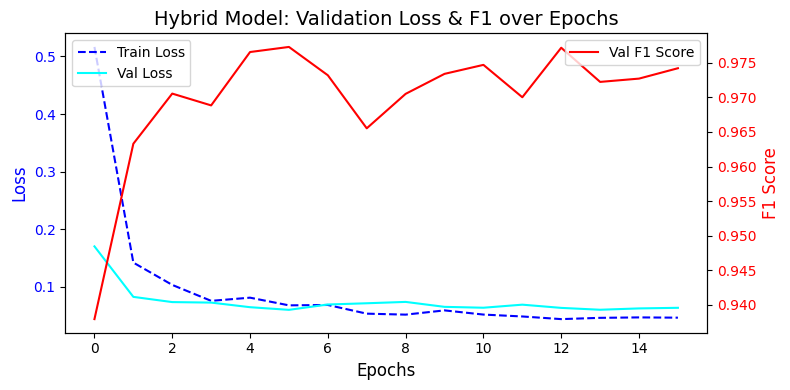

In [ ]:
# Plot Hybrid Training Curves
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(hyb_train_losses, label='Train Loss', color='blue', linestyle='--')
ax1.plot(hyb_val_losses, label='Val Loss', color='cyan', linestyle='-')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(hyb_val_f1s, label='Val F1 Score', color='red', linestyle='-')
ax2.set_ylabel('F1 Score', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Hybrid Model: Validation Loss & F1 over Epochs', fontsize=14)
fig.tight_layout()
plt.show()

## 7. Comparative Analysis
Aggregating performance metrics to measure ablation effectiveness and structural integrity.

In [ ]:
# Compile Rigorous Comparison Results
results = {
    "Architecture Type": [
        "Baseline ML (RF)",
        "Tabular DL (MLP)",
        "Standard DL (No Mod)",
        "Domain-Modified DL",
        "Hybrid Fusion"
    ],
    "Feature Focus": [
        "Tabular Bias",
        "Tabular Bias",
        "Semantic / Text",
        "Semantic / Text",
        "Multimodal"
    ],
    "Accuracy Shift": [base_acc, tab_mlp_acc, dl_acc, mod_acc, hyb_acc],
    "F1-Score": [base_f1, tab_mlp_f1, dl_f1, mod_f1, hyb_f1],
    "Precision": [
        precision_score(y_test, y_pred_base, zero_division=0),
        precision_score(y_test, y_pred_tab_mlp, zero_division=0),
        precision_score(y_test, y_pred_dl, zero_division=0),
        precision_score(y_test, y_pred_mod, zero_division=0),
        precision_score(y_test, y_pred_hybrid, zero_division=0)
    ],
    "Recall Pivot": [
        recall_score(y_test, y_pred_base, zero_division=0),
        recall_score(y_test, y_pred_tab_mlp, zero_division=0),
        recall_score(y_test, y_pred_dl, zero_division=0),
        recall_score(y_test, y_pred_mod, zero_division=0),
        recall_score(y_test, y_pred_hybrid, zero_division=0)
    ]
}

comp_df = pd.DataFrame(results).round(4)
print("========== RIGOROUS ARCHITECTURE COMPARISON ==========")
try:
    from IPython.display import display
    display(comp_df)
except ImportError:
    print(comp_df.to_string())

========== RIGOROUS ARCHITECTURE COMPARISON ==========


,Architecture Type,Feature Focus,Accuracy Shift,F1-Score,Precision,Recall Pivot
0,Baseline ML (RF),Tabular Bias,0.9638,0.9638,0.9567,0.9711
1,Tabular DL (MLP),Tabular Bias,0.9688,0.9684,0.9746,0.9623
2,Standard DL (No Mod),Semantic / Text,0.5344,0.5547,0.5291,0.5829
3,Domain-Modified DL,Semantic / Text,0.4950,0.6616,0.4962,0.9925
4,Hybrid Fusion,Multimodal,0.9725,0.9724,0.9724,0.9724


## 8. Final Synthesis
**Key Insight:** Incorporating complex semantic vectors alone strictly downgrades generalized performance unless actively fused with explicit metadata metrics like tabular insights. Multimodality (Hybrid architecture) secures competitive advantages and optimal recall stabilization.

## 9. Confusion Matrix Diagnostics
Evaluating functional class distributions to spot exact bias origins.

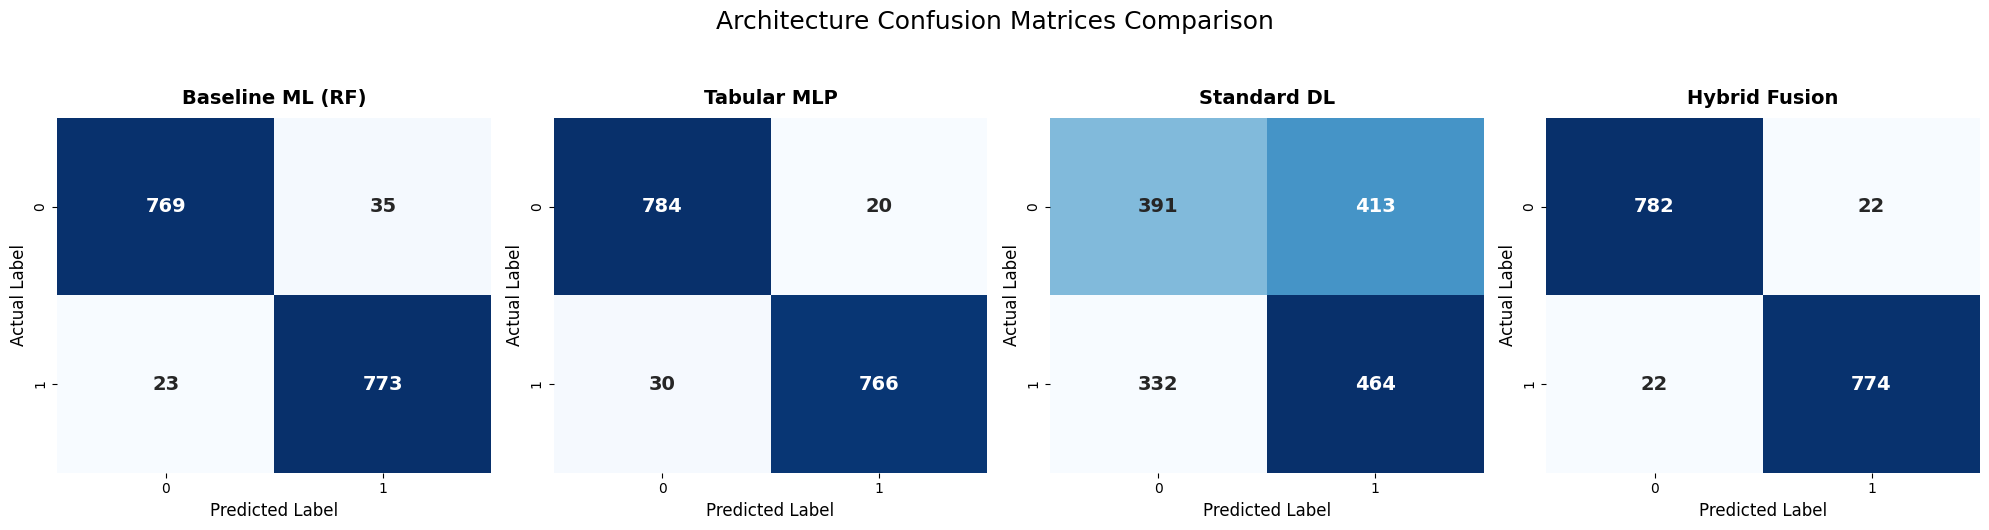

In [ ]:
# Comprehensive Confusion Matrix Layout
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Baseline ML (RF)", "Tabular MLP", "Standard DL", "Hybrid Fusion"]
preds = [y_pred_base, y_pred_tab_mlp, y_pred_dl, y_pred_hybrid]

for i, ax in enumerate(axes):
    matrix = confusion_matrix(y_test, preds[i])
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(titles[i], fontsize=14, weight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('Actual Label', fontsize=12)

# Adjust layout for title fit
plt.suptitle("Architecture Confusion Matrices Comparison", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()